Импорты и воспроизводимость

In [1]:
!pip install evaluate seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.1 MB/s eta 0:00:00
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=2c61c482e3322c8470758d6b0fea6524d6614c42754c3e1c406583fbdb1b7c69
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


In [2]:
import os
import re
import json
import random
import numpy as np
import torch
from datasets import Dataset, DatasetDict, load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    AutoModelForMaskedLM,
    DataCollatorForTokenClassification,
    DataCollatorForLanguageModeling,
    DataCollatorForWholeWordMask,
    TrainingArguments,
    Trainer,
    pipeline
)
import evaluate
import numpy as np
seqeval_metric = evaluate.load("seqeval")
import seqeval
from sklearn.metrics import classification_report
from huggingface_hub import hf_hub_download


SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Device: cuda


Загрузка и подготовка данных

In [3]:
def load_factrueval_flat():
    """
    Загружает FactRuEval-2016 в плоском формате.

    Датасет имеет вложенную структуру: каждый JSON-файл содержит
    объект с полем "data", которое является списком примеров.
    Каждый пример: {id, tokens: List[str], ner_tags_str: List[str], ner_tags: List[int]}
    """
    dataset_dict = {}

    splits_map = {
        "train": "train_data.json",
        "validation": "dev_data.json",
        "test": "test_data.json"
    }

    for split_name, filename in splits_map.items():
        file_path = hf_hub_download(
            repo_id="gusevski/factrueval2016",
            filename=filename,
            repo_type="dataset"
        )

        with open(file_path, 'r', encoding='utf-8') as f:
            raw = json.load(f)

        # Извлекаем список примеров из вложенной структуры
        items = raw["data"] if isinstance(raw, dict) and "data" in raw else raw

        examples = {"id": [], "tokens": [], "ner_tags": [], "ner_tags_str": []}
        for item in items:
            examples["id"].append(item["id"])
            examples["tokens"].append(item["tokens"])
            examples["ner_tags"].append(item["ner_tags"])
            examples["ner_tags_str"].append(item["ner_tags_str"])

        dataset_dict[split_name] = Dataset.from_dict(examples)
        print(f"{split_name}: {len(dataset_dict[split_name])}")

    return DatasetDict(dataset_dict)

# Загружаем датасет
ds = load_factrueval_flat()

train_data.json:   0%|          | 0.00/7.62M [00:00<?, ?B/s]

train: 7746


dev_data.json:   0%|          | 0.00/2.48M [00:00<?, ?B/s]

validation: 2582


test_data.json:   0%|          | 0.00/2.57M [00:00<?, ?B/s]

test: 2582


Извлечение меток и настройка маппинга

In [4]:
all_tags = set()
for split in ds.values():
    for example in split:
        all_tags.update(example["ner_tags_str"])

tag_order = ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC']
label_names = [t for t in tag_order if t in all_tags] + [t for t in sorted(all_tags) if t not in tag_order]

id2label = {i: label for i, label in enumerate(label_names)}
label2id = {label: i for i, label in enumerate(label_names)}

print(f"Labels ({len(label_names)}): {label_names}")
print(f"Mapping: {label2id}")

Labels (7): ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC']
Mapping: {'O': 0, 'B-PER': 1, 'I-PER': 2, 'B-ORG': 3, 'I-ORG': 4, 'B-LOC': 5, 'I-LOC': 6}


Токенизация с выравниванием меток

In [5]:
def tokenize_and_align_labels(example, tokenizer, label_all_tokens=True):
    """
    Токенизация с корректным выравниванием NER-меток.

    Проблема: BPE-токенизатор может разбивать слово на несколько подтокенов.
    Решение: присваиваем метку первому подтокену, остальные помечаем -100 (игнорируются в loss).

    Args:
        example: dict с полями "tokens" и "ner_tags"
        tokenizer: экземпляр AutoTokenizer
        label_all_tokens: если True, все подтокены слова получают его метку
    """
    tokenized = tokenizer(
        example["tokens"],
        is_split_into_words=True,
        truncation=True,
        max_length=512,
        padding=False
    )

    labels = []
    word_ids = tokenized.word_ids()
    previous_word_idx = None

    for word_idx in word_ids:
        if word_idx is None:
            # CLS, SEP, padding
            labels.append(-100)
        elif word_idx != previous_word_idx:
            # Первый подтокен слова — берём оригинальную метку
            labels.append(example["ner_tags"][word_idx])
        else:
            # Последующие подтокены того же слова
            if label_all_tokens:
                labels.append(example["ner_tags"][word_idx])
            else:
                labels.append(-100)  # Игнорируем при вычислении лосса
        previous_word_idx = word_idx

    tokenized["labels"] = labels
    return tokenized

model_name = "DeepPavlov/rubert-base-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Применяем токенизацию ко всем сплитам
tokenized_ds = ds.map(
    lambda x: tokenize_and_align_labels(x, tokenizer),
    batched=False,
    remove_columns=ds["train"].column_names
)

print(f"Tokenized: train={len(tokenized_ds['train'])}, val={len(tokenized_ds['validation'])}, test={len(tokenized_ds['test'])}")

config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/7746 [00:00<?, ? examples/s]

Map:   0%|          | 0/2582 [00:00<?, ? examples/s]

Map:   0%|          | 0/2582 [00:00<?, ? examples/s]

Tokenized: train=7746, val=2582, test=2582


Инициализация модели и метрик

In [6]:
model = AutoModelForTokenClassification.from_pretrained(
    model_name,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True)

seqeval = evaluate.load("seqeval")

def compute_metrics(eval_pred):
    """Вычисление NER-метрик через evaluate.seqeval"""
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=2) # Берём класс с макс. вероятностью

    # Восстанавливаем предсказания и метки, исключая -100 (special tokens)
    true_predictions, true_labels = [], []
    for pred, label in zip(predictions, labels):
        tp, tl = [], []
        for p, l in zip(pred, label):
            if l != -100:
                tp.append(id2label[p])
                tl.append(id2label[l])
        true_predictions.append(tp)
        true_labels.append(tl)

    results = seqeval_metric.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"]
    }

#Data collator для динамического паддинга
data_collator = DataCollatorForTokenClassification(tokenizer)

print(f"Model: {model_name}, Labels: {len(label_names)}")

pytorch_model.bin:   0%|          | 0.00/714M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                        

Model: DeepPavlov/rubert-base-cased, Labels: 7


Настройка обучения

In [7]:

training_args = TrainingArguments(
    output_dir="./ner_baseline",
    learning_rate=8e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32, # eval менее нагружен, можем увеличить размер batch
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    fp16=True,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_steps=50,
    eval_steps=200,
    save_steps=200,
    seed=SEED,
    report_to="none",
    save_total_limit=2 # Храним только 2 лучших чекпоинта для экономии памяти
)

# Инициализация Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("Zero-shot evaluation")
zero_shot = trainer.evaluate()
print(f"Zero-shot F1: {zero_shot['eval_f1']:.4f}")

print("\nStarting fine-tuning")
train_result = trainer.train()
print(f"Training loss: {train_result.metrics['train_loss']:.4f}")

print("\nPost-training evaluation")
baseline_results = trainer.evaluate(eval_dataset=tokenized_ds["test"])
print(f"Fine-tuned Test F1: {baseline_results['eval_f1']:.4f}")
print(f"Precision: {baseline_results['eval_precision']:.4f}, Recall: {baseline_results['eval_recall']:.4f}")

Zero-shot evaluation


Zero-shot F1: 0.0443

Starting fine-tuning


Epoch,Training Loss,Validation Loss,Model Preparation Time,Precision,Recall,F1,Accuracy
1,0.041889,0.042101,0.015500,0.948770,0.955709,0.952227,0.988335
2,0.016996,0.025445,0.015500,0.970580,0.974130,0.972352,0.993662
3,0.010826,0.023799,0.015500,0.970009,0.981308,0.975626,0.994209
4,0.002837,0.027483,0.015500,0.974771,0.978599,0.976681,0.994674
5,0.004217,0.030194,0.015500,0.976599,0.977922,0.977260,0.994375


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Training loss: 0.0208

Post-training evaluation


Fine-tuned Test F1: 0.9804
Precision: 0.9786, Recall: 0.9822


MLM pre-training перед NER

In [8]:
mlm_model = AutoModelForMaskedLM.from_pretrained(model_name)
mlm_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=True, mlm_probability=0.15)

# Для MLM нам не нужны метки NER, только input_ids
mlm_ds = ds.map(
    lambda x: tokenizer(x["tokens"], is_split_into_words=True, truncation=True, max_length=512),
    batched=False,
    remove_columns=ds["train"].column_names
)

mlm_args = TrainingArguments(
    output_dir="./mlm_pretrain",
    learning_rate=1e-4,  # Чуть выше, т.к. задача проще
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    eval_strategy="epoch",
    save_strategy="epoch",
    fp16=True,
    seed=SEED,
    report_to="none",
    logging_steps=50
)

mlm_trainer = Trainer(
    model=mlm_model,
    args=mlm_args,
    train_dataset=mlm_ds["train"],
    eval_dataset=mlm_ds["validation"],
    processing_class=tokenizer,
    data_collator=mlm_collator,
)

print(" MLM Pre-training")
mlm_trainer.train()
mlm_trainer.save_model("./mlm_pretrain/final")

#  Fine-tuning NER на предобученной модели
ner_model_mlm = AutoModelForTokenClassification.from_pretrained(
    "./mlm_pretrain/final", num_labels=len(label_names), id2label=id2label, label2id=label2id
)

trainer_mlm = Trainer(
    model=ner_model_mlm,
    args=training_args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["validation"],
    processing_class=tokenizer,
    data_collator=DataCollatorForTokenClassification(tokenizer),
    compute_metrics=compute_metrics,
)

trainer_mlm.train()
mlm_results = trainer_mlm.evaluate(eval_dataset=tokenized_ds["test"])
print(f"MLM+NER Test F1: {mlm_results['eval_f1']:.4f}")

Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie bert.embeddings.word_embeddings.weight to cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie cls.predictions.bias to cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BertForMaskedLM LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.pooler.dense.weight     | UNEXPECTED |  | 
bert.pooler.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight  | UNEXPECTED |  | 
cls.seq_relationship.bias    | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be igno

Map:   0%|          | 0/7746 [00:00<?, ? examples/s]

Map:   0%|          | 0/2582 [00:00<?, ? examples/s]

Map:   0%|          | 0/2582 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

MLM+NER Test F1: 0.9820


Concept Masking

In [9]:
import torch
from torch.nn.utils.rnn import pad_sequence
from transformers import AutoModelForMaskedLM, TrainingArguments, Trainer

class DataCollatorForConceptMasking:
    def __init__(self, tokenizer, mlm_probability=0.8):
        self.tokenizer = tokenizer
        self.mlm_probability = mlm_probability

    def __call__(self, examples):
        input_ids = [e["input_ids"] for e in examples]
        input_ids = pad_sequence(
            [torch.tensor(x) for x in input_ids],
            batch_first=True,
            padding_value=self.tokenizer.pad_token_id
        )

        # Извлекаем NER метки  для определения сущностей
        ner_labels = [e["labels"] for e in examples]
        ner_labels = pad_sequence(
            [torch.tensor(x) for x in ner_labels],
            batch_first=True,
            padding_value=-100
        )

        labels = input_ids.clone()

        # 0 - это тег 'O', -100 - паддинг/special tokens.
        # Всё, что > 0, является частью сущности (B-... или I-...)
        is_entity = (ner_labels > 0) & (ner_labels != -100)

        # Случайный отбор сущностей для маскирования (чтобы не маскировать 100% всегда)
        random_mask = torch.rand(labels.shape, device=labels.device) < self.mlm_probability
        mask_indices = is_entity & random_mask

        # Заменяем токены сущностей на [MASK]
        input_ids[mask_indices] = self.tokenizer.mask_token_id


        return {
            "input_ids": input_ids,
            "attention_mask": (input_ids != self.tokenizer.pad_token_id).long(),
            "labels": labels
        }

ds_concept = tokenized_ds


concept_collator = DataCollatorForConceptMasking(
    tokenizer=tokenizer,
    mlm_probability=0.8  # Маскируем 80% найденных сущностей
)

mlm_args_concept = TrainingArguments(
    output_dir="./concept_mlm_pretrain",
    learning_rate=5e-5,
    per_device_train_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="no",
    fp16=torch.cuda.is_available(),
    seed=SEED,
    report_to="none",
    logging_steps=50
)

concept_model = AutoModelForMaskedLM.from_pretrained(model_name)

concept_trainer = Trainer(
    model=concept_model,
    args=mlm_args_concept,
    train_dataset=ds_concept["train"],
    eval_dataset=ds_concept["validation"],
    data_collator=concept_collator,
)

print("=== Concept Masking (Entity MLM) Pre-training ===")
concept_trainer.train()
concept_trainer.save_model("./concept_mlm_pretrain/final")

#Fine-tuning на NER с использованием весов от Concept Masking ===
ner_model_concept = AutoModelForTokenClassification.from_pretrained(
    "./concept_mlm_pretrain/final",
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

ner_trainer_concept = Trainer(
    model=ner_model_concept,
    args=training_args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["validation"],
    processing_class=tokenizer,
    data_collator=DataCollatorForTokenClassification(tokenizer),
    compute_metrics=compute_metrics,
)

print("=== NER fine-tuning after Concept Masking ===")
ner_trainer_concept.train()
concept_results = ner_trainer_concept.evaluate(eval_dataset=tokenized_ds["test"])
print(f"Concept+MLM+NER Test F1: {concept_results['eval_f1']:.4f}")

Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie bert.embeddings.word_embeddings.weight to cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie cls.predictions.bias to cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BertForMaskedLM LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.pooler.dense.weight     | UNEXPECTED |  | 
bert.pooler.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight  | UNEXPECTED |  | 
cls.seq_relationship.bias    | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be igno

=== Concept Masking (Entity MLM) Pre-training ===


Epoch,Training Loss,Validation Loss
1,0.183289,0.205425
2,0.149687,0.194883
3,0.138732,0.197440


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Concept+MLM+NER Test F1: 0.9816


Синтетическая разметка

In [17]:
import torch
import gc
from transformers import pipeline, AutoModelForTokenClassification, Trainer, TrainingArguments, DataCollatorForTokenClassification
from datasets import Dataset

# Очистка памяти
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    gc.collect()

# Загрузка учителя на CPU
teacher_ner = pipeline(
    "token-classification",
    model="Babelscape/wikineural-multilingual-ner",
    aggregation_strategy="simple",
    device=-1
)

# Загрузка корпуса
synthetic_raw = load_dataset("data-silence/lenta.ru_2-extended", split="train")
synthetic_raw = synthetic_raw.shuffle(seed=SEED).select(range(500))  # Уменьшаем для экономии памяти

text_col = "text" if "text" in synthetic_raw.column_names else synthetic_raw.column_names[0]

def generate_synthetic_ner(text, max_length=256):
    try:
        entities = teacher_ner(text[:max_length])
        tokens = text[:max_length].split()
        if not tokens:
            return None
        ner_tags = ["O"] * len(tokens)

        for ent in entities:
            ent_text = ent.get('word', '')
            ent_type = ent.get('entity_group', 'MISC')
            if not ent_text:
                continue
            for i, tok in enumerate(tokens):
                if tok in ent_text or ent_text in tok:
                    if i < len(ner_tags):
                        ner_tags[i] = f"B-{ent_type.upper()}" if i == 0 or ner_tags[i-1] == "O" else f"I-{ent_type.upper()}"

        numeric_tags = [label2id.get(tag, label2id.get("O", 0)) for tag in ner_tags]
        return {"tokens": tokens, "ner_tags": numeric_tags}
    except:
        return None

# Генерация
print("Generating synthetic labels...")
synthetic_examples = []
for i, item in enumerate(synthetic_raw):
    text = item.get(text_col)
    if not text or not isinstance(text, str):
        continue
    result = generate_synthetic_ner(text)
    if result and len(result["tokens"]) > 0:
        synthetic_examples.append(result)

print(f"Generated {len(synthetic_examples)} examples")

# Объединение и дообучение
if len(synthetic_examples) > 0:
    synthetic_ds = Dataset.from_list(synthetic_examples)

    # Токенизация синтетических данных
    def tokenize_synthetic(example):
        return tokenize_and_align_labels(example, tokenizer)

    synthetic_tokenized = synthetic_ds.map(tokenize_synthetic, batched=False)

    # Объединяем (берём меньше синтетики чтобы не доминировала)
    n_synth = min(len(synthetic_tokenized), len(tokenized_ds["train"]) // 4)
    combined_train = Dataset.from_list(
        list(tokenized_ds["train"]) + list(synthetic_tokenized.shuffle(seed=SEED).select(range(n_synth)))
    )

    # Очищаем память перед обучением
    del teacher_ner, synthetic_raw, synthetic_ds, synthetic_tokenized
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        gc.collect()

    ner_model_synth = AutoModelForTokenClassification.from_pretrained(
        model_name, num_labels=len(label_names), id2label=id2label, label2id=label2id
    )

    synthetic_trainer = Trainer(
        model=ner_model_synth,
        args=training_args,
        train_dataset=combined_train,
        eval_dataset=tokenized_ds["validation"],
        processing_class=tokenizer,
        data_collator=DataCollatorForTokenClassification(tokenizer),
        compute_metrics=compute_metrics,
    )

    print("Training with synthetic data")
    synthetic_trainer.train()
    synthetic_results = synthetic_trainer.evaluate(eval_dataset=tokenized_ds["test"])
    print(f"Synthetic+NER Test F1: {synthetic_results['eval_f1']:.4f}")
else:
    print("No synthetic examples generated")
    synthetic_results = {"eval_f1": 0.0, "eval_precision": 0.0, "eval_recall": 0.0}

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: Babelscape/wikineural-multilingual-ner
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating synthetic labels...
Generated 500 examples


Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Synthetic+NER Test F1: 0.9813


Сравнение результатов и выводы

Сводная таблица результатов:


,Method,F1,Precision,Recall
0,2. MLM Pre-training,0.9820,0.9800,0.9841
1,3. Concept Masking,0.9816,0.9797,0.9836
2,4. Synthetic Data,0.9813,0.9793,0.9833
3,1. Baseline,0.9804,0.9786,0.9822


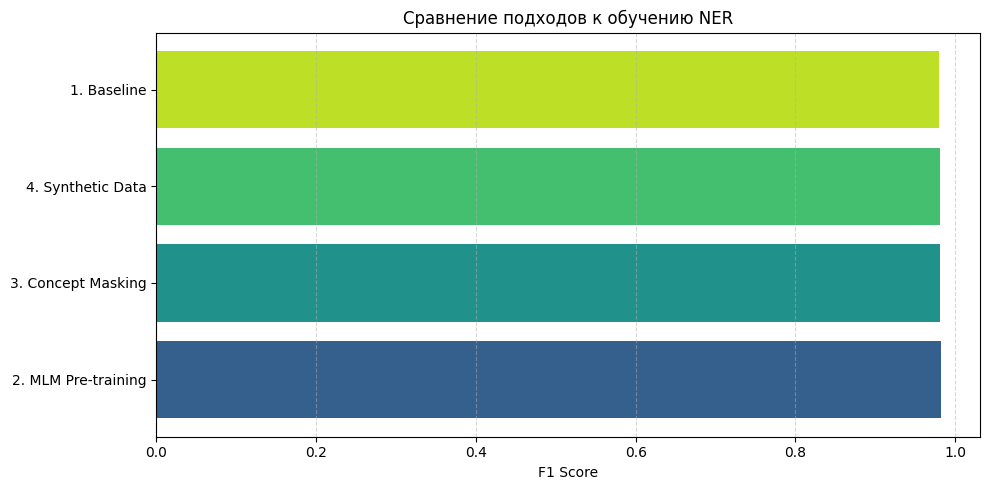


Лучшая модель: 2. MLM Pre-training (F1 = 0.9820)


Наибольший прирост качества дал метод: 2. MLM Pre-training.


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import evaluate

# Сбор результатов в список
results_data = []

# Функция для безопасного добавления результатов
def add_res(name, res_dict, trainer_obj):
    if res_dict and isinstance(res_dict, dict):
        results_data.append({
            "Method": name,
            "F1": res_dict.get("eval_f1", 0),
            "Precision": res_dict.get("eval_precision", 0),
            "Recall": res_dict.get("eval_recall", 0),
            "Trainer": trainer_obj
        })

# Добавляем результаты (проверяем, существуют ли переменные)
if 'baseline_results' in locals(): add_res("1. Baseline", baseline_results, trainer)
if 'mlm_results' in locals(): add_res("2. MLM Pre-training", mlm_results, trainer_mlm)
if 'concept_results' in locals(): add_res("3. Concept Masking", concept_results, ner_trainer_concept)
if 'synthetic_results' in locals(): add_res("4. Synthetic Data", synthetic_results, synthetic_trainer)

df = pd.DataFrame(results_data)

if not df.empty:
    # Сортировка по F1
    df = df.sort_values("F1", ascending=False).reset_index(drop=True)

    # Красивый вывод таблицы
    pd.options.display.float_format = '{:.4f}'.format
    print("Сводная таблица результатов:")
    display(df[["Method", "F1", "Precision", "Recall"]])

    # График
    plt.figure(figsize=(10, 5))
    plt.barh(df["Method"], df["F1"], color=plt.cm.viridis(np.linspace(0.3, 0.9, len(df))))
    plt.xlabel("F1 Score")
    plt.title("Сравнение подходов к обучению NER")
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # Анализ лучшей модели
    best = df.iloc[0]
    print(f"\nЛучшая модель: {best['Method']} (F1 = {best['F1']:.4f})")

    # Получаем предсказания лучшей модели на тесте
    predictions = best['Trainer'].predict(tokenized_ds["test"])
    preds = np.argmax(predictions.predictions, axis=2)
    labels = predictions.label_ids

    # Преобразование в списки строк для метрик
    true_preds, true_labels = [], []
    for p, l in zip(preds, labels):
        tp, tl = [], []
        for pi, li in zip(p, l):
            if li != -100:
                tp.append(id2label[pi])
                tl.append(id2label[li])
        true_preds.append(tp)
        true_labels.append(tl)

    # Расчет метрик (ИСПРАВЛЕНИЕ: убран output_dict=True)
    seqeval_metric = evaluate.load("seqeval")
    report = seqeval_metric.compute(predictions=true_preds, references=true_labels)

    # Вывод по классам
    class_stats = []
    for cls in label_names:
        if cls in report:
            class_stats.append({
                "Class": cls,
                "Precision": report[cls]['precision'],
                "Recall": report[cls]['recall'],
                "F1": report[cls]['f1'],
                "Count": report[cls]['number']
            })

    df_classes = pd.DataFrame(class_stats)
    if not df_classes.empty:
        print("\nМетрики по классам (Entity-level):")
        display(df_classes.sort_values("F1", ascending=False))

    # Выводы
    print(f"Наибольший прирост качества дал метод: {best['Method']}.")


else:
    print("Нет данных для сравнения. Убедитесь, что предыдущие ячейки выполнены.")